# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from collections import Counter
from collections import defaultdict


In [2]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, classification_report,
                             roc_curve, auc)
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np

In [4]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

In [5]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [6]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [7]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.calibration import CalibratedClassifierCV  # ← needed for predict_proba
import numpy as np

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report

In [9]:
def print_dist(y, label, binary=False):
    unique, counts = np.unique(y, return_counts=True)
    proportions    = counts / counts.sum()
    prefix         = 'binary=' if binary else 'sii='
    df = pd.DataFrame({
        'Class':      [f'{prefix}{u}' for u in unique],
        'Count':      counts,
        'Proportion': proportions.round(4),
        'Percentage': (proportions * 100).round(2)
    })
    print(f"\n{'='*60}")
    print(f"  SET: {label}")
    print(df.to_string(index=False))

# READ DATAFRAME

In [10]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [11]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,5,0,16.877316,46.000,50.800000,82.152821,4.611111,17.883041,6.500000,2.0,2.668550,1492.000000,41.586230,9.213770,1.0,19.541300,32.690900,2.0
1,1,9,0,14.035590,48.000,46.000000,90.666667,8.000000,18.204545,11.000000,2.0,2.579490,1498.650000,42.029150,3.970850,1.0,15.410700,27.055200,0.0
2,2,10,1,16.648696,56.500,75.600000,82.333333,27.000000,12.450000,10.000000,3.0,3.389932,1796.890000,59.788250,15.811750,2.0,25.634700,42.380000,0.0
3,3,9,0,18.292347,56.000,81.600000,79.000000,23.000000,18.204545,7.000000,3.0,3.841910,1923.440000,62.775700,18.824300,2.0,26.479800,45.996600,1.0
4,4,18,1,17.937682,54.626,76.139461,90.152104,12.000000,26.463732,8.003205,3.0,12.054014,2652.510000,60.327711,15.811750,2.0,29.912400,42.380000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,7,1,16.130585,46.070,48.700252,81.861037,6.500000,18.075000,7.000000,1.0,2.625946,1490.847845,45.526276,3.173977,1.0,18.024600,31.583004,0.0
8378,8456,10,1,17.300000,56.130,77.531978,79.833333,8.500000,13.575000,5.000000,3.0,4.987853,1678.330810,69.880763,7.651215,1.0,22.983200,36.475662,1.0
8379,8457,10,1,40.937571,49.560,143.030726,82.166667,21.500000,16.840263,9.500000,4.0,3.990512,1547.346725,107.979706,35.051020,2.0,31.594712,35.106855,0.0
8380,8458,15,1,22.500000,63.790,130.236404,88.395702,10.000000,26.417470,10.500000,2.0,4.967841,1674.735823,103.517750,26.718654,2.0,46.467581,57.530686,2.0


In [58]:
df.loc[df["sii"] == 3, "sii"] = 2
print(df["sii"].value_counts())

sii
0.0    5794
1.0    1567
2.0    1021
Name: count, dtype: int64


In [59]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8382, 17)
y shape : (8382,)
Classes : [0. 1. 2.]
Class counts : {0.0: 5794, 1.0: 1567, 2.0: 1021}


# Data Preparation

In [60]:
X.shape

(8382, 17)

In [61]:
np.unique(y, return_counts=True)

(array([0., 1., 2.]), array([5794, 1567, 1021]))

In [62]:
Counter(y)

Counter({2.0: 1021, 0.0: 5794, 1.0: 1567})

In [63]:
ctr = Counter(y)
ctr

Counter({2.0: 1021, 0.0: 5794, 1.0: 1567})

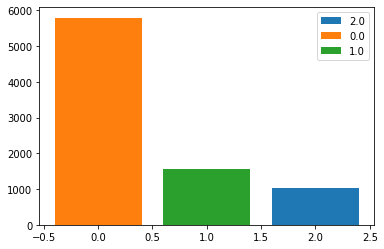

In [64]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange','tab:green','tab:red'])
plt.legend()
plt.show()

## Data Partitioning

In [65]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [67]:
X_train.shape

(5867, 17)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [68]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2.]), array([4055, 1097,  715])),
 (array([0., 1., 2.]), array([1739,  470,  306])))

In [69]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.691153911709562

In [70]:

print(f"Train samples : {len(y_train)}")
print(f"Test samples  : {len(y_test)}")

Train samples : 5867
Test samples  : 2515


# CASCADE LINEAR SVM

## model

In [71]:
param_list = [
    # l2 + hinge — requires dual=True
    {
        'C':            [0.001,0.01, 0.1, 1, 10],
        'penalty':      ['l1', 'l2'],
        'class_weight': ['balanced']
    }
]

In [72]:
def train_one_step_svm(X_train, y_binary, X_test, y_test_binary, step_name,
                       n_iter=50, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    # ── Random search on LinearSVC ────────────────────────────────────────────
    # NOTE: search on LinearSVC directly (faster)
    # calibration is applied AFTER finding best params
    random_search = RandomizedSearchCV(
        LinearSVC(random_state=random_state),
        param_distributions=param_list,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_macro',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
        error_score='raise',
    )
    random_search.fit(X_train, y_binary)

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    # ── Wrap best model with calibration to enable predict_proba ─────────────
    # LinearSVC has no predict_proba natively
    # CalibratedClassifierCV adds it via Platt scaling
    calibrated_model = CalibratedClassifierCV(
        LinearSVC(**random_search.best_params_,
                  random_state=random_state),
        cv=5
    )
    calibrated_model.fit(X_train, y_binary)

    # ── Predictions ───────────────────────────────────────────────────────────
    y_pred_binary = calibrated_model.predict(X_test)
    y_proba       = calibrated_model.predict_proba(X_test)[:, 1]  # P(positive)

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'not {step_name}', step_name]
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {step_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # ── Reports ───────────────────────────────────────────────────────────────
    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    print(f"    AUC                    : {roc_auc:.4f}")

    return calibrated_model     # ← return calibrated model, not raw LinearSVC

## split 

In [73]:
# 
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2.]
Train samples  : 5867
Test samples   : 2515


In [74]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


  SET: TRAIN
  Class  Count  Proportion  Percentage
sii=0.0   4055      0.6912       69.12
sii=1.0   1097      0.1870       18.70
sii=2.0    715      0.1219       12.19

  SET: TEST
  Class  Count  Proportion  Percentage
sii=0.0   1739      0.6915       69.15
sii=1.0    470      0.1869       18.69
sii=2.0    306      0.1217       12.17


### class 0

In [75]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [76]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   1812      0.3088       30.88
binary=1   4055      0.6912       69.12

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    776      0.3085       30.85
binary=1   1739      0.6915       69.15


In [77]:
from imblearn.over_sampling import SMOTE
over_dic={0:3500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 4055, 0: 3500})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [78]:
print_dist(y_res, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   3500      0.4633       46.33
binary=1   4055      0.5367       53.67

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    776      0.3085       30.85
binary=1   1739      0.6915       69.15



  STEP: sii=0
  Training samples : 7555
  Positive class   : 4055 samples
  Negative class   : 3500 samples


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=50. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



  Best params : {'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.001}
  Best CV F1  : 0.6265
  Test F1     : 0.6731


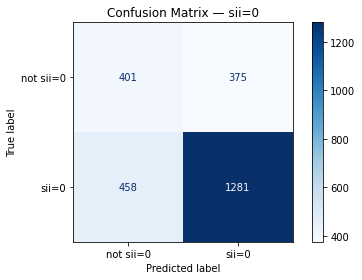

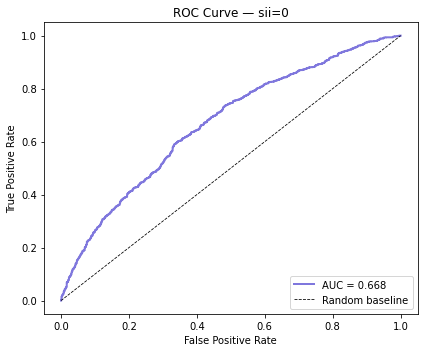

              precision    recall  f1-score   support

   not sii=0       0.47      0.52      0.49       776
       sii=0       0.77      0.74      0.75      1739

    accuracy                           0.67      2515
   macro avg       0.62      0.63      0.62      2515
weighted avg       0.68      0.67      0.67      2515


  Confusion Matrix breakdown:
    TN (correct negatives) : 401
    FP (false positives)   : 375
    FN (false negatives)   : 458
    TP (correct positives) : 1281
    AUC                    : 0.6678


In [79]:
models[0] = train_one_step_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=0')

In [80]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_te)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_te.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1656 samples


### class 1 

In [81]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [82]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1812
  Remaining test  : 1234

  SET: TRAIN after step 1
  Class  Count  Proportion  Percentage
sii=1.0   1097      0.6054       60.54
sii=2.0    715      0.3946       39.46

  SET: TEST  after step 1
  Class  Count  Proportion  Percentage
sii=0.0    458      0.3712       37.12
sii=1.0    470      0.3809       38.09
sii=2.0    306      0.2480       24.80


In [83]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [84]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    715      0.3946       39.46
binary=1   1097      0.6054       60.54

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    764      0.6191       61.91
binary=1    470      0.3809       38.09


In [85]:
from imblearn.over_sampling import SMOTE
over_dic={0:900}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 1097, 0: 900})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [86]:
print_dist(y_res, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    900      0.4507       45.07
binary=1   1097      0.5493       54.93

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    764      0.6191       61.91
binary=1    470      0.3809       38.09



  STEP: sii=1
  Training samples : 1997
  Positive class   : 1097 samples
  Negative class   : 900 samples


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=50. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



  Best params : {'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.001}
  Best CV F1  : 0.5793
  Test F1     : 0.5440


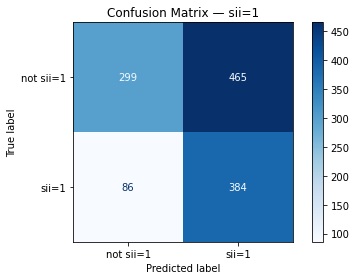

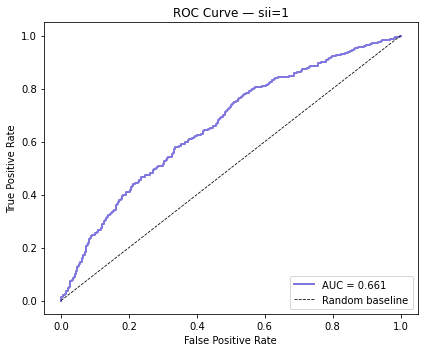

              precision    recall  f1-score   support

   not sii=1       0.78      0.39      0.52       764
       sii=1       0.45      0.82      0.58       470

    accuracy                           0.55      1234
   macro avg       0.61      0.60      0.55      1234
weighted avg       0.65      0.55      0.54      1234


  Confusion Matrix breakdown:
    TN (correct negatives) : 299
    FP (false positives)   : 465
    FN (false negatives)   : 86
    TP (correct positives) : 384
    AUC                    : 0.6610


In [87]:
models[1] = train_one_step_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=1')

In [88]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 849 samples


### class 2

In [89]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 715
  Remaining test  : 850


In [90]:
y_pred_final[original_idx] = 2
step_results[2] = {
    'step_name':    'sii=2 (remaining)',
    'y_true_bin':   (y_te == 2).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=2 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=2 : 850 samples (all remaining)


## RESULTS

In [91]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2515        1739 1281 375 458     0.7736  0.7366 0.7546
   sii=1 vs [2,3]       1234         470  384 465  86     0.4523  0.8170 0.5823
sii=2 (remaining)        850         306  306 544   0     0.3600  1.0000 0.5294


In [92]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.74      0.85      1739
       sii=1       1.00      0.82      0.90       470
       sii=2       0.36      1.00      0.53       306

    accuracy                           0.78      2515
   macro avg       0.79      0.85      0.76      2515
weighted avg       0.92      0.78      0.82      2515



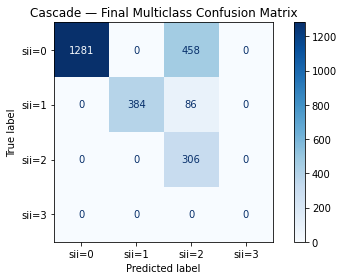

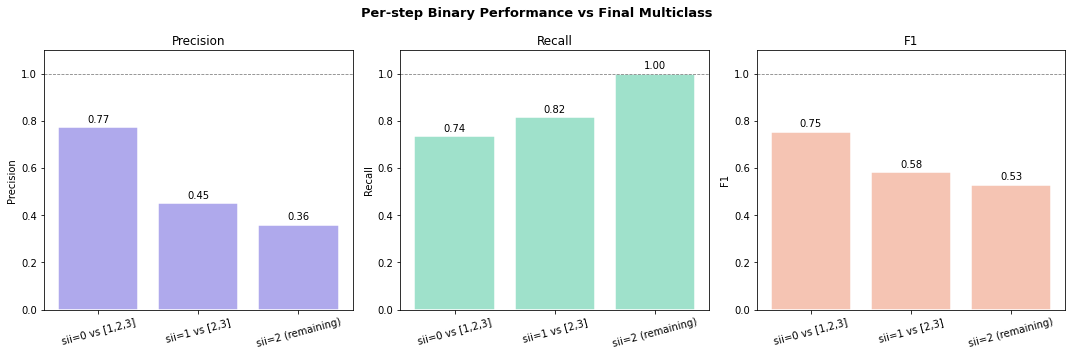

In [93]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [94]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1739   predicted: 1281
  sii=1 → true: 470    predicted: 384
  sii=2 → true: 306    predicted: 850
  sii=3 → true: 0      predicted: 0


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


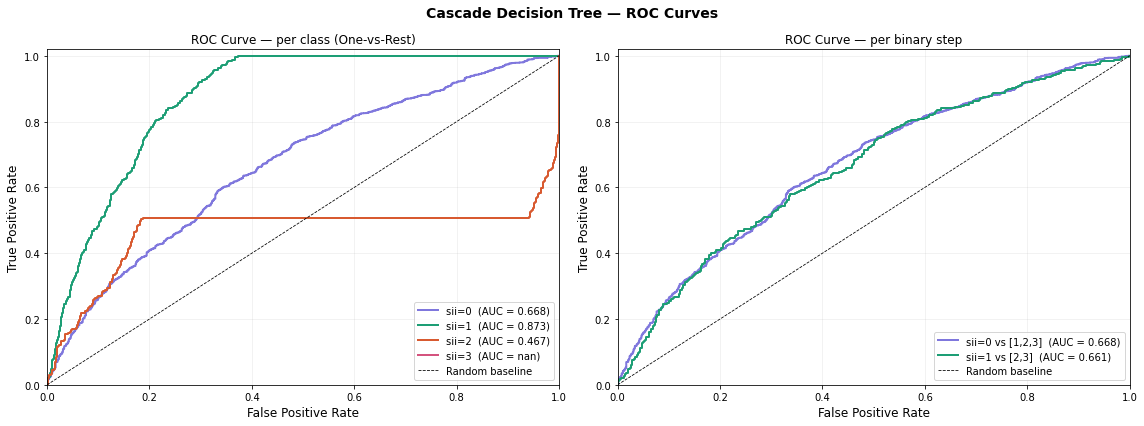


  AUC SUMMARY
  sii=0    → AUC = 0.6678
  sii=1    → AUC = 0.8734
  sii=2    → AUC = 0.4668
  sii=3    → AUC = nan

  Macro AUC    : nan
  Weighted AUC : 0.6818


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [95]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)

# CASCADE NON LINEAR SVM

## model

In [96]:
param_list = [
    # RBF kernel — most commonly used non-linear kernel
    {
        'C':            [0.001,0.01, 0.1, 1],#, 100],
        'kernel':       ['rbf'],
        'gamma':        ['auto'],
        'class_weight': ['balanced']
    },
    # # Polynomial kernel — good for image/text data
    {
         'C':            [0.001, 0.01, 0.1, 1],#, 100],, 100],
         'kernel':       ['poly'],
         'gamma':        ['auto'],
         'degree':       [2, 3, 4, 5],       # polynomial degree
         'coef0':        [0, 0.1, 0.5],   # independent term
         'class_weight': ['balanced'],
    },
    # # Sigmoid kernel — similar to neural network activation
    {
         'C':            [0.001, 0.01, 0.1, 1],#, 100],, 100],
         'kernel':       ['sigmoid'],
         'gamma':        ['auto'],
         'coef0':        [0, 0.1, 0.5],
         'class_weight': ['balanced']
    }
]

In [97]:
def train_one_step_non_svm(X_train, y_binary, X_test, y_test_binary, step_name,
                       n_iter=50, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    random_search = RandomizedSearchCV(
            SVC(probability=True, random_state=random_state),
            param_distributions=param_list,
            cv=KFold(n_splits=n_splits, shuffle=True,random_state=random_state),
            scoring='f1_weighted',
            n_jobs=-1,
            refit=True,
            n_iter=n_iter,
            random_state=random_state
    )
    random_search.fit(X_train, y_binary)

    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_binary)

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    # ── Predictions ───────────────────────────────────────────────────────────
    y_pred_binary = best_model.predict(X_test)
    y_proba       = best_model.predict_proba(X_test)[:, 1]  # ← P(positive class)
                                                             #   only 2 columns in binary

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'not {step_name}', step_name]
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {step_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # ── Reports ───────────────────────────────────────────────────────────────
    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    print(f"    AUC                    : {roc_auc:.4f}")

    return best_model

## split 

In [98]:
# 
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2.]
Train samples  : 5867
Test samples   : 2515


In [99]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


  SET: TRAIN
  Class  Count  Proportion  Percentage
sii=0.0   4055      0.6912       69.12
sii=1.0   1097      0.1870       18.70
sii=2.0    715      0.1219       12.19

  SET: TEST
  Class  Count  Proportion  Percentage
sii=0.0   1739      0.6915       69.15
sii=1.0    470      0.1869       18.69
sii=2.0    306      0.1217       12.17


### class 0

In [100]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [101]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   1812      0.3088       30.88
binary=1   4055      0.6912       69.12

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    776      0.3085       30.85
binary=1   1739      0.6915       69.15


In [102]:
from imblearn.over_sampling import SMOTE
over_dic={0:3500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled dataset shape Counter({1: 4055, 0: 3500})


In [103]:
print_dist(y_res, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   3500      0.4633       46.33
binary=1   4055      0.5367       53.67

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    776      0.3085       30.85
binary=1   1739      0.6915       69.15



  STEP: sii=0
  Training samples : 7555
  Positive class   : 4055 samples
  Negative class   : 3500 samples



  Best params : {'kernel': 'poly', 'gamma': 'auto', 'degree': 5, 'coef0': 0.5, 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.6656
  Test F1     : 0.6242


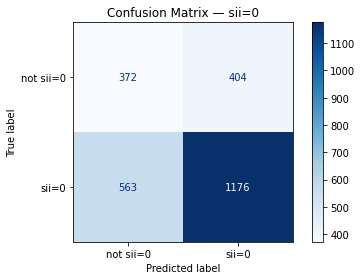

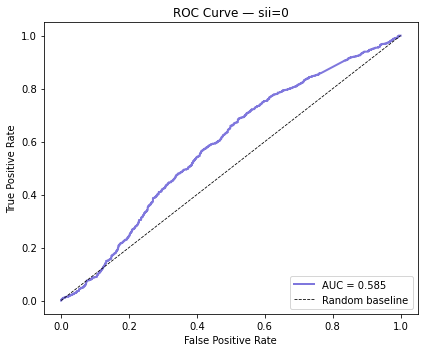

              precision    recall  f1-score   support

   not sii=0       0.40      0.48      0.43       776
       sii=0       0.74      0.68      0.71      1739

    accuracy                           0.62      2515
   macro avg       0.57      0.58      0.57      2515
weighted avg       0.64      0.62      0.62      2515


  Confusion Matrix breakdown:
    TN (correct negatives) : 372
    FP (false positives)   : 404
    FN (false negatives)   : 563
    TP (correct positives) : 1176
    AUC                    : 0.5846


In [104]:
models[0] = train_one_step_non_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=0')

In [105]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_te)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_te.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1580 samples


### class 1 

In [106]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [107]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1812
  Remaining test  : 1339

  SET: TRAIN after step 1
  Class  Count  Proportion  Percentage
sii=1.0   1097      0.6054       60.54
sii=2.0    715      0.3946       39.46

  SET: TEST  after step 1
  Class  Count  Proportion  Percentage
sii=0.0    563      0.4205       42.05
sii=1.0    470      0.3510       35.10
sii=2.0    306      0.2285       22.85


In [108]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [109]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    715      0.3946       39.46
binary=1   1097      0.6054       60.54

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    869       0.649        64.9
binary=1    470       0.351        35.1


In [110]:
from imblearn.over_sampling import SMOTE
over_dic={0:900}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 1097, 0: 900})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [111]:
print_dist(y_res, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    900      0.4507       45.07
binary=1   1097      0.5493       54.93

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    869       0.649        64.9
binary=1    470       0.351        35.1



  STEP: sii=1
  Training samples : 1997
  Positive class   : 1097 samples
  Negative class   : 900 samples

  Best params : {'kernel': 'poly', 'gamma': 'auto', 'degree': 3, 'coef0': 0.1, 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.5856
  Test F1     : 0.5172


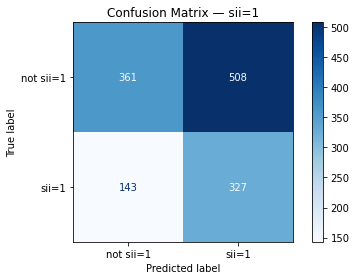

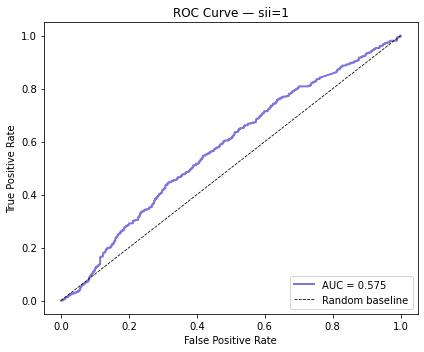

              precision    recall  f1-score   support

   not sii=1       0.72      0.42      0.53       869
       sii=1       0.39      0.70      0.50       470

    accuracy                           0.51      1339
   macro avg       0.55      0.56      0.51      1339
weighted avg       0.60      0.51      0.52      1339


  Confusion Matrix breakdown:
    TN (correct negatives) : 361
    FP (false positives)   : 508
    FN (false negatives)   : 143
    TP (correct positives) : 327
    AUC                    : 0.5752


In [112]:
models[1] = train_one_step_non_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=1')

In [113]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 835 samples


### class 3 

In [114]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 715
  Remaining test  : 1012


In [115]:
y_pred_final[original_idx] = 2
step_results[2] = {
    'step_name':    'sii=2 (remaining)',
    'y_true_bin':   (y_te == 2).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=2 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=2 : 1012 samples (all remaining)


## RESULTS

In [116]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2515        1739 1176 404 563     0.7443  0.6763 0.7086
   sii=1 vs [2,3]       1339         470  327 508 143     0.3916  0.6957 0.5011
sii=2 (remaining)       1012         306  306 706   0     0.3024  1.0000 0.4643


In [117]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.68      0.81      1739
       sii=1       1.00      0.70      0.82       470
       sii=2       0.30      1.00      0.46       306

    accuracy                           0.72      2515
   macro avg       0.77      0.79      0.70      2515
weighted avg       0.92      0.72      0.77      2515



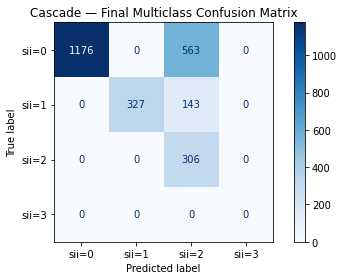

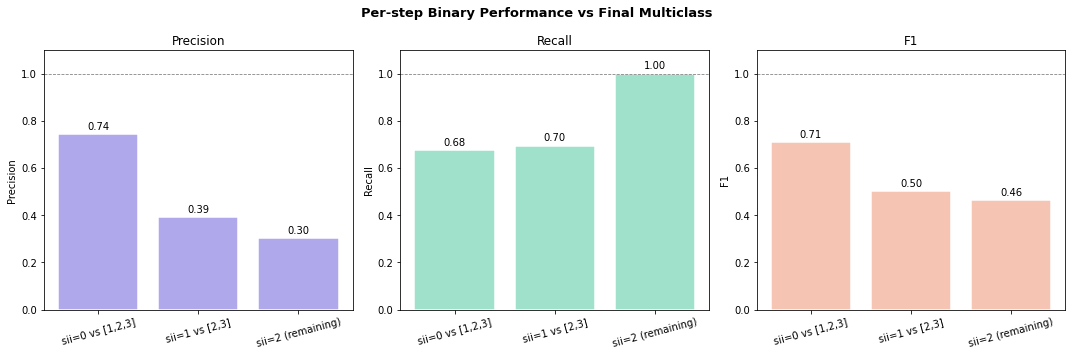

In [118]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [119]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1739   predicted: 1176
  sii=1 → true: 470    predicted: 327
  sii=2 → true: 306    predicted: 1012
  sii=3 → true: 0      predicted: 0


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


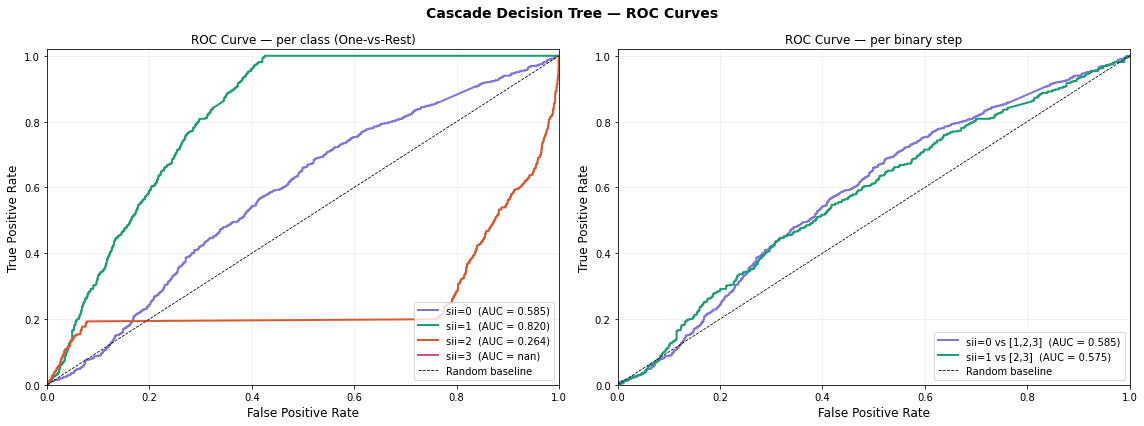


  AUC SUMMARY
  sii=0    → AUC = 0.5846
  sii=1    → AUC = 0.8195
  sii=2    → AUC = 0.2636
  sii=3    → AUC = nan

  Macro AUC    : nan
  Weighted AUC : 0.5894


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [120]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)

# NON LINEAR SVM

  RANDOM SEARCH — SVM non lineare
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/


── Best hyperparameters found ──────────────────────────
  kernel         : sigmoid
  gamma          : auto
  coef0          : 0
  class_weight   : balanced
  C              : 1

  F1-weighted (CV): 0.5239

── Classification Report (Test set) ───────────────────────
              precision    recall  f1-score   support

         0.0       0.71      0.76      0.73      1739
         1.0       0.18      0.14      0.16       470
         2.0       0.14      0.12      0.13       306

    accuracy                           0.57      2515
   macro avg       0.34      0.34      0.34      2515
weighted avg       0.54      0.57      0.55      2515

  F1-weighted (Test):  0.5533
  F1-weighted (CV):    0.5239
  Delta CV→Test:       +0.0294  (ok)


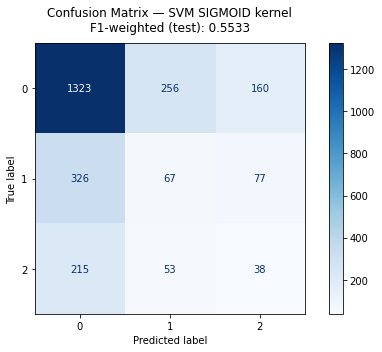


  Confusion matrix salvata in confusion_matrix_svm.png


In [121]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 30

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_list = [
    # RBF kernel
    {
        "C":            [0.001, 0.01, 0.1, 1],
        "kernel":       ["rbf"],
        "gamma":        ["auto"],
        "class_weight": ["balanced"],
    },
    # Polynomial kernel
    {
        "C":            [0.001, 0.01, 0.1, 1],
        "kernel":       ["poly"],
        "gamma":        ["auto"],
        "degree":       [2, 3, 4, 5],
        "coef0":        [0, 0.1, 0.5],
        "class_weight": ["balanced"],
    },
    # Sigmoid kernel
    {
        "C":            [0.001, 0.01, 0.1, 1],
        "kernel":       ["sigmoid"],
        "gamma":        ["auto"],
        "coef0":        [0, 0.1],
        "class_weight": ["balanced"],
    },
]

"""over_dic={1:1500, 2:1500, 3:500}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
X_res, y_res = over.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))"""

# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — SVM non lineare")
print("=" * 60)

random_search = RandomizedSearchCV(
    SVC(probability=True, random_state=random_state, max_iter=2000),
    param_distributions=param_list,
    cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True,          # riaddestra automaticamente sul dataset completo
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<15}: {value}")

print(f"\n  F1-weighted (CV): {random_search.best_score_:.4f}")

# ── Modello migliore (già refit sul training set completo) ───────────────────
best_model = random_search.best_estimator_

# ── Previsioni sul test set ──────────────────────────────────────────────────
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)   # probabilità per classe

# ── Metriche ─────────────────────────────────────────────────────────────────
print("\n── Classification Report (Test set) ───────────────────────")
print(classification_report(y_test, y_pred))

f1_test = f1_score(y_test, y_pred, average="weighted")
print(f"  F1-weighted (Test):  {f1_test:.4f}")
print(f"  F1-weighted (CV):    {random_search.best_score_:.4f}")
delta = f1_test - random_search.best_score_
print(f"  Delta CV→Test:       {delta:+.4f}  {'(ok)' if abs(delta) < 0.05 else '(attenzione: possibile overfitting)'}")

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(
    f"Confusion Matrix — SVM {random_search.best_params_['kernel'].upper()} kernel\n"
    f"F1-weighted (test): {f1_test:.4f}",
    fontsize=12,
    pad=12,
)
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150)
plt.show()
print("\n  Confusion matrix salvata in confusion_matrix_svm.png")